In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Set style for plots
sns.set_theme(style="whitegrid")

In [3]:

df = pd.read_csv('wine_quality_merged.csv')
# Display first 5 rows
print("Dataset Head:")
display(df.head())

# Check dataset shape and info
print("\nDataset Info:")
print(df.info())

# Summary statistics
print("\nSummary Statistics:")
display(df.describe())

# Check for missing values
print("\nMissing Values Count:")
print(df.isnull().sum())

Dataset Head:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB
None

Summary Statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000



Missing Values Count:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64


/tmp/ipykernel_1238/3188329974.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


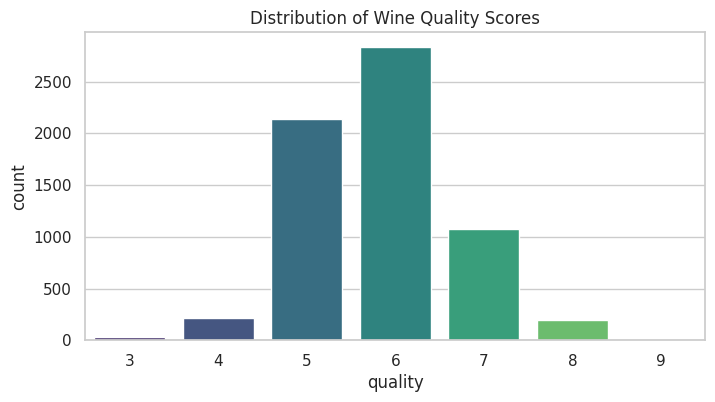

In [6]:
# Exploratory Data Analysis: Check class distribution of target 'quality'
plt.figure(figsize=(8, 4))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Distribution of Wine Quality Scores')
plt.show()

df['is_good_quality'] = (df['quality'] >= 7).astype(int)

In [7]:
# Separate features (X) and target (y)
X = df.drop(['quality', 'is_good_quality'], axis=1)
y = df['is_good_quality']

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (5197, 12)
Testing set shape: (1300, 12)


In [9]:
# Drop any non-numeric columns or target-related columns if they accidentally ended up in X_train
X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test.select_dtypes(include=[np.number])

# Now run your scaling code again
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

X_train_std = scaler_standard.fit_transform(X_train)
X_test_std = scaler_standard.transform(X_test)

X_train_mm = scaler_minmax.fit_transform(X_train)
X_test_mm = scaler_minmax.transform(X_test)

In [11]:
# Train and evaluate baseline KNN (K=5, uniform weights, euclidean) for each scaling method
scalings = {
    "No Scaling": (X_train, X_test),
    "StandardScaler": (X_train_std, X_test_std),
    "MinMaxScaler": (X_train_mm, X_test_mm)
}

scaling_results = []
for name, (X_tr, X_te) in scalings.items():
    knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='uniform')
    knn.fit(X_tr, y_train)
    y_pred = knn.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    scaling_results.append({"Scaling Method": name, "Accuracy": acc, "F1-Score": f1})

scaling_df = pd.DataFrame(scaling_results)
print("Comparison of Feature Scaling Techniques:")
display(scaling_df)

Comparison of Feature Scaling Techniques:


,Scaling Method,Accuracy,F1-Score
0,No Scaling,0.800000,0.783768
1,StandardScaler,0.831538,0.824556
2,MinMaxScaler,0.824615,0.818508


In [12]:
# Using StandardScaler data for hyperparameter tuning
X_tr_opt, X_te_opt = X_train_std, X_test_std

k_values = range(1, 21)
metrics = ['euclidean', 'manhattan', 'minkowski']
weights_options = ['uniform', 'distance']

results = []

for k in k_values:
    for m in metrics:
        for w in weights_options:
            knn = KNeighborsClassifier(n_neighbors=k, metric=m, weights=w)
            knn.fit(X_tr_opt, y_train)
            y_pred = knn.predict(X_te_opt)

            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='weighted')

            results.append({
                'K': k,
                'Metric': m,
                'Weight': w,
                'Accuracy': acc,
                'F1-Score': f1
            })

results_df = pd.DataFrame(results)
print("Top 5 configurations based on Accuracy:")
display(results_df.sort_values(by='Accuracy', ascending=False).head())

Top 5 configurations based on Accuracy:


,K,Metric,Weight,Accuracy,F1-Score
55,10,euclidean,distance,0.881538,0.877632
59,10,minkowski,distance,0.881538,0.877632
81,14,manhattan,distance,0.880000,0.875597
117,20,manhattan,distance,0.878462,0.872340
79,14,euclidean,distance,0.877692,0.872145


Text(0, 0.5, 'Accuracy')

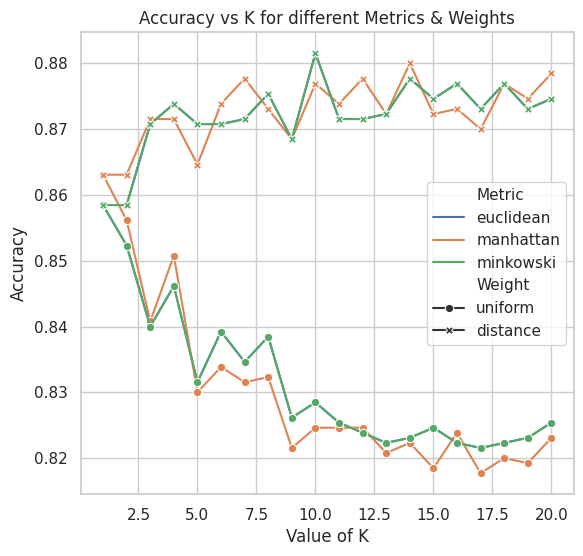

In [13]:
# Plotting Accuracy vs K and F1-Score vs K
plt.figure(figsize=(14, 6))

# Accuracy vs K Plot
plt.subplot(1, 2, 1)
sns.lineplot(data=results_df, x='K', y='Accuracy', hue='Metric', style='Weight', markers=True, dashes=False)
plt.title('Accuracy vs K for different Metrics & Weights')
plt.xlabel('Value of K')
plt.ylabel('Accuracy')


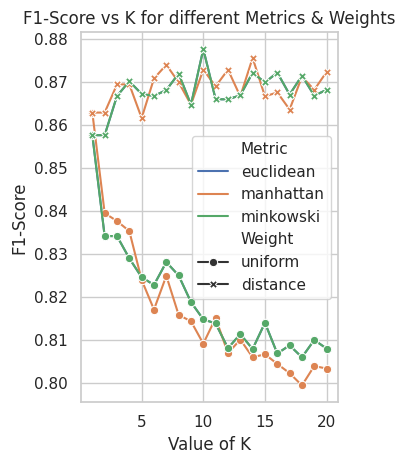

In [14]:
# F1-Score vs K Plot
plt.subplot(1, 2, 2)
sns.lineplot(data=results_df, x='K', y='F1-Score', hue='Metric', style='Weight', markers=True, dashes=False)
plt.title('F1-Score vs K for different Metrics & Weights')
plt.xlabel('Value of K')
plt.ylabel('F1-Score')

plt.tight_layout()
plt.show()

In [15]:
# Find the row with the maximum accuracy/F1-score
best_row = results_df.loc[results_df['Accuracy'].idxmax()]

print("--- BEST KNN MODEL CONFIGURATION ---")
print(f"Optimal K: {best_row['K']}")
print(f"Optimal Distance Metric: {best_row['Metric']}")
print(f"Optimal Weighting Method: {best_row['Weight']}")
print(f"Best Accuracy: {best_row['Accuracy']:.4f}")
print(f"Best F1-Score: {best_row['F1-Score']:.4f}")


--- BEST KNN MODEL CONFIGURATION ---
Optimal K: 10
Optimal Distance Metric: euclidean
Optimal Weighting Method: distance
Best Accuracy: 0.8815
Best F1-Score: 0.8776


In [16]:
# Train final model with best parameters to show classification report & confusion matrix
best_knn = KNeighborsClassifier(
    n_neighbors=int(best_row['K']),
    metric=best_row['Metric'],
    weights=best_row['Weight']
)
best_knn.fit(X_tr_opt, y_train)
final_preds = best_knn.predict(X_te_opt)

print("\nClassification Report:")
print(classification_report(y_test, final_preds))



Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      1044
           1       0.74      0.62      0.67       256

    accuracy                           0.88      1300
   macro avg       0.82      0.78      0.80      1300
weighted avg       0.88      0.88      0.88      1300



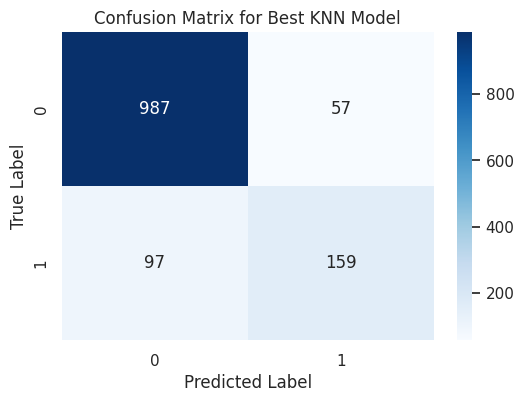

In [17]:
# Confusion Matrix Plot
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Best KNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Why this combination performs best:

1. **Choice of K (K = 10):**
   - A moderate value like $K=10$ strikes the right balance between bias and variance.
   - Smaller values (like $K=1$ or $3$) made the model overly sensitive to noise in the dataset, leading to overfitting.
   - On the other hand, larger values oversmoothed the decision boundaries, causing the model to miss subtle patterns for the minority class.

2. **Euclidean Distance Metric:**
   - Because our feature set consists of continuous, standardized chemical properties of wine (like density, pH, and alcohol levels), the Euclidean distance effectively measures straight-line geometric similarity in continuous multi-dimensional space.

3. **Distance-Based Weighting:**
   - Setting `weights='distance'` gave closer neighbors a stronger vote than neighbors further away.
   - This prevents boundary overlap issues where majority class samples located further out might otherwise incorrectly sway the classification of borderline instances.
"""

print(markdown_text)